In [12]:
import pyarrow.parquet as pa
import matplotlib.pyplot as plt
import seaborn as sns

table = pa.read_table('9/tmp/450_DecisionTreeClassifier.parquet')
df = table.to_pandas() 

In [13]:
df.columns

Index(['data_id', 'target_unique_vals', 'NumberOfFeatures_post_processing',
       'pairwise_complexity_post_processing', 'base_fit_time',
       'base_score_time', 'base_test_f1_macro', 'base_train_f1_macro',
       'base_test_neg_log_loss', 'base_train_neg_log_loss',
       'base_test_neg_brier_score', 'base_train_neg_brier_score',
       'base_n_jobs_cv', 'base_cpu', 'base_ram', 'base_test_f1', 'base_time',
       'pdc_fit_time', 'pdc_score_time', 'pdc_test_f1_macro',
       'pdc_train_f1_macro', 'pdc_test_neg_log_loss', 'pdc_train_neg_log_loss',
       'pdc_test_neg_brier_score', 'pdc_train_neg_brier_score',
       'pdc_n_jobs_cv', 'pdc_cpu', 'pdc_ram', 'pdc_test_f1', 'pdc_time',
       'pdc_ram_max', 'data_time', 'name', 'version', 'uploader', 'status',
       'format', 'MajorityClassSize', 'MaxNominalAttDistinctValues',
       'MinorityClassSize', 'NumberOfClasses', 'NumberOfFeatures',
       'NumberOfInstances', 'NumberOfInstancesWithMissingValues',
       'NumberOfMissingValues

In [14]:
df.shape

(1, 51)

In [ ]:
df.drop(['data_id', 'pairwise_complexity_post_processing', 'base_n_jobs_cv', 'base_ram', 'base_time',
       'pdc_fit_time', 'pdc_score_time', 'pdc_test_f1_macro',
       'pdc_n_jobs_cv', 'pdc_ram', 'pdc_time',
       'pdc_ram_max', 'data_time', 'name', 'version', 'uploader', 'status',
       'format', 'MajorityClassSize', 'MaxNominalAttDistinctValues',
       'MinorityClassSize', 'NumberOfClasses', 'NumberOfFeatures',
       'NumberOfInstances', 'NumberOfInstancesWithMissingValues',
       'NumberOfMissingValues', 'NumberOfNumericFeatures',
       'NumberOfSymbolicFeatures', 'MinorityClassRatio', 'complexity',
       'pairwise_complexity', 'NumberOfInstances2'], axis=1, inplace=True)

In [31]:
df.columns

Index(['target_unique_vals', 'NumberOfFeatures_post_processing',
       'base_fit_time', 'base_score_time', 'base_test_f1_macro',
       'base_train_f1_macro', 'base_test_neg_log_loss',
       'base_train_neg_log_loss', 'base_test_neg_brier_score',
       'base_train_neg_brier_score', 'base_cpu', 'base_test_f1',
       'pdc_train_f1_macro', 'pdc_test_neg_log_loss', 'pdc_train_neg_log_loss',
       'pdc_test_neg_brier_score', 'pdc_train_neg_brier_score', 'pdc_cpu',
       'pdc_test_f1'],
      dtype='object')

In [ ]:
df.tail()

,target_unique_vals,NumberOfFeatures_post_processing,base_fit_time,base_score_time,base_test_f1_macro,base_train_f1_macro,base_test_neg_log_loss,base_train_neg_log_loss,base_test_neg_brier_score,base_train_neg_brier_score,base_cpu,base_test_f1,pdc_train_f1_macro,pdc_test_neg_log_loss,pdc_train_neg_log_loss,pdc_test_neg_brier_score,pdc_train_neg_brier_score,pdc_cpu,pdc_test_f1
95,2,60,"[0.009875297546386719, 0.009479045867919922, 0...","[0.007773637771606445, 0.008069992065429688, 0...","[0.8332387975042541, 0.7306122448979592, 0.752...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[-6.0072755648528595, -9.440004459054492, -8.5...","[-2.220446049250313e-16, -2.220446049250313e-1...","[-0.16666666666666666, -0.2619047619047619, -0...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....",87.6,0.730031,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[-0.3992517204966578, -0.4881359442434812, -1....","[-2.220446049250313e-16, -2.220446049250313e-1...","[-0.13573204486887813, -0.16402096142354447, -...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....",79.8,0.772418
136,2,3,"[0.0027456283569335938, 0.0027370452880859375,...","[0.005623817443847656, 0.006650686264038086, 0...","[0.5826193390452876, 0.49917898193760263, 0.55...","[0.97837646224743, 0.9731506849315068, 0.98405...","[-12.23069379891258, -14.771989093900473, -12....","[-0.022726137067539405, -0.028291721655508178,...","[-0.3467741935483871, -0.4098360655737705, -0....","[-0.00819672131147541, -0.01020408163265306, -...",93.9,0.545786,"[0.97837646224743, 0.9739522422335155, 0.98405...","[-1.0891048241729835, -1.0156606748843697, -1....","[-0.042389289106436585, -0.05252181288181885, ...","[-0.28097249103184346, -0.2942470468670696, -0...","[-0.00862923839410187, -0.01086088483143804, -...",85.2,0.551853
71,3,5,"[0.004171848297119141, 0.002863168716430664, 0...","[0.0064203739166259766, 0.014228105545043945, ...","[0.5851449275362319, 0.575091575091575, 0.7336...","[0.9666627598062196, 0.9833229101521784, 0.983...","[-12.86056167282661, -14.417461355646859, -9.6...","[-0.054930614433405696, -0.022913956382147167,...",None,None,90.5,0.604986,"[0.9666314609085692, 0.9833229101521784, 0.983...","[-1.759565542873369, -5.504298703408982, -4.03...","[-0.10489189139599567, -0.04385117551878694, -...",None,None,91.7,0.615522
129,2,13,"[0.0028533935546875, 0.0027153491973876953, 0....","[0.007288932800292969, 0.005359172821044922, 0...","[0.697054698457223, 0.7904761904761904, 0.7551...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[-10.67960100418286, -7.342225690375716, -8.67...","[-2.220446049250313e-16, -2.220446049250313e-1...","[-0.2962962962962963, -0.2037037037037037, -0....","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....",92.2,0.745536,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[-0.5623184110699296, -0.4582378801797798, -1....","[-2.220446049250313e-16, -2.220446049250313e-1...","[-0.19655303772587812, -0.1570530517084678, -0...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....",85.0,0.771998
146,2,34,"[0.019396305084228516, 0.009240150451660156, 0...","[0.006420612335205078, 0.006197452545166016, 0...","[0.8765217391304347, 0.9082167832167831, 0.885...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[-4.061256719900524, -3.08945600478147, -3.604...","[-2.220446049250313e-16, -2.220446049250313e-1...","[-0.11267605633802817, -0.08571428571428572, -...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....",91.9,0.871198,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[-0.7714234349225595, -0.640562390914212, -1.2...","[-2.220446049250313e-16, -2.220446049250313e-1...","[-0.09505861119814586, -0.05277047256763195, -...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....",79.7,0.894265


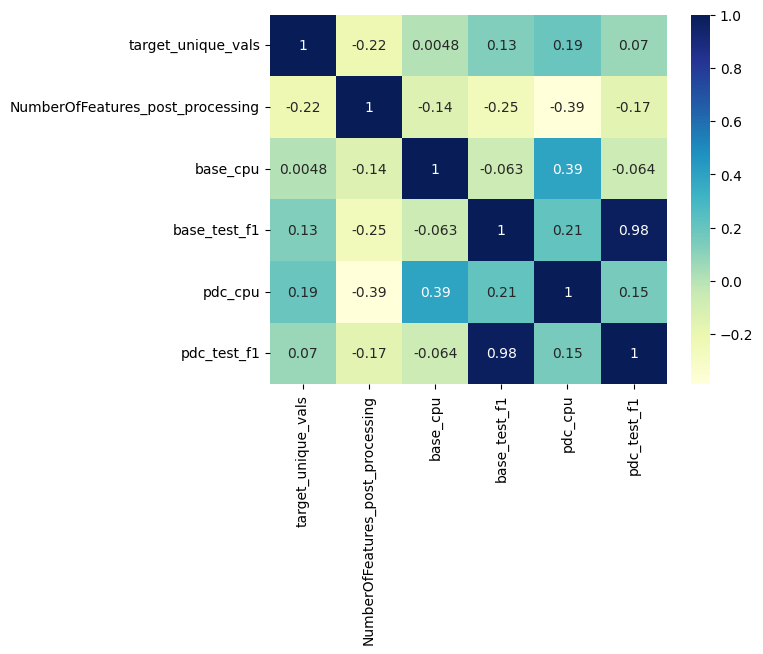

In [32]:
# Plotting correlation heatmap
dataplot = sns.heatmap(df.corr(numeric_only=True), cmap="YlGnBu", annot=True)

# Displaying heatmap
plt.show()